In [1]:
import torch
import torchvision
import numpy as np
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()['images'])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

sample_images.size()

torch.Size([2, 427, 640, 3])

In [2]:
sample_images = sample_images.permute(0,3,1,2)
sample_images.shape

torch.Size([2, 3, 427, 640])

In [3]:
import torchvision.transforms.v2 as T

cropped_images = T.CenterCrop((70, 120))(sample_images)
cropped_images.shape

torch.Size([2, 3, 70, 120])

In [4]:
import torch.nn as nn 

torch.manual_seed(52)

conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)

fmaps.shape

torch.Size([2, 32, 64, 114])

In [5]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding='same')
fmaps = conv_layer(cropped_images)

fmaps.shape

torch.Size([2, 32, 70, 120])

## pooling layers

In [6]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [7]:
import torch.nn.functional as F

class DepthPool(nn.Module):
    def __init__(self, kernel_size, padding=0, stride=None):
       super().__init__()
       self.kernel_size = kernel_size
       self.padding = padding 
       self.stride = stride if stride is not None else kernel_size
       
    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height*width)
        Z = Z.permute(0, 2, 1)
        Z = F.max_pool1d(Z, kernel_size=self.kernel_size, padding=self.padding, stride=self.stride)
        Z = Z.permute(0, 2, 1)
        return Z.view(batch, -1, height, width)

In [8]:
# global average pooling layer1
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)

In [9]:
output = torch.mean(cropped_images, dim=(2,3), keepdim=True)

In [10]:
from functools import partial

DefConv2d = partial(nn.Conv2d, kernel_size=3, padding='same')

model = nn.Sequential(DefConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
                      DefConv2d(in_channels=64, out_channels=128), nn.ReLU(),
                      DefConv2d(in_channels=128, out_channels=128), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
                      DefConv2d(in_channels=128, out_channels=256), nn.ReLU(),
                      DefConv2d(in_channels=256, out_channels=256), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
                      nn.Flatten(), nn.Linear(2304, 128), nn.ReLU(), nn.Dropout(0.5),
                      nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5),
                      nn.Linear(64, 10)).to('cuda')

### xception

In [11]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channels)
        self.pointwise_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        
    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

In [12]:
def create_list(n, starting_value):
    ls = []
    for i in range(n):
        ls.append(starting_value+i)
    return ls

create_list(5, 11)

[11, 12, 13, 14, 15]

In [13]:
def filter_multiples(lst):
    return [x+1 if x%3==0 and x%2==1 else x for x in lst]

lst = [1, 2, 3, 4, 5, 6, 7, 8, 9]
filter_multiples(lst)

[1, 2, 4, 4, 5, 6, 7, 8, 10]

## Residual Model

In [14]:
class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        DefaultConv2d = partial(nn.Conv2d, kernel_size=3, stride=1, padding=1, bias=False)
        self.main_layers = nn.Sequential(DefaultConv2d(in_channels, out_channels, stride=stride), nn.BatchNorm2d(out_channels), nn.ReLU(),
                                         DefaultConv2d(out_channels, out_channels), nn.BatchNorm2d(out_channels))
        if stride > 1:
            self.skip_connection = nn.Sequential(DefaultConv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0), nn.BatchNorm2d(out_channels))
        else:
            self.skip_connection = nn.Identity()
            
    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

In [15]:
#testing
[64] * 3 + [128] * 4 + [256] * 6 + [512] * 3

[64, 64, 64, 128, 128, 128, 128, 256, 256, 256, 256, 256, 256, 512, 512, 512]

In [16]:
class ResNet34(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False), 
                  nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(kernel_size=3, padding=1, stride=2)]
        prev_filters = 64
        for filters in [64]*3 + [128]*4 + [256]*6 + [512]*3:
            stride = 1 if prev_filters == filters else 2
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters
        layers += [nn.AdaptiveAvgPool2d(output_size=1), nn.Flatten(), nn.LazyLinear(10)]
        self.resnet = nn.Sequential(*layers)
        
    def forward(self, inputs):
        return self.resnet(inputs)

## pretrained models

In [17]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
convnext = torchvision.models.convnext_base(weights=weights).to('cuda')

In [18]:
transforms = weights.transforms()
preproced_imgs = transforms(sample_images)

In [19]:
model.eval()
with torch.no_grad():
    y_logits = convnext(preproced_imgs.to('cuda'))
    
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([698, 599], device='cuda:0')

In [20]:
class_names = weights.meta['categories']
[class_names[class_id] for class_id in y_pred]

['palace', 'honeycomb']

In [21]:
y_top3_logits, y_top3_id = torch.topk(y_logits, k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_top3_id]

[['palace', 'monastery', 'lakeside'], ['honeycomb', 'daisy', 'earthstar']]

In [22]:
y_top3_logits.softmax(dim=1)

tensor([[0.6184, 0.3094, 0.0722],
        [0.5865, 0.2868, 0.1267]], device='cuda:0')

## TRansfe learning

In [23]:
DefaultFlowers102 = partial(torchvision.datasets.Flowers102, root='datasets', transform=weights.transforms(), download=True)

train_set = DefaultFlowers102(split='train')
valid_set = DefaultFlowers102(split='val')
test_set  = DefaultFlowers102(split='test')

In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader  = DataLoader(test_set, batch_size=32)

In [25]:
class_names = train_set.classes
class_names[:5]

['pink primrose',
 'hard-leaved pocket orchid',
 'canterbury bells',
 'sweet pea',
 'english marigold']

In [26]:
[name for name, child in convnext.named_children()]

['features', 'avgpool', 'classifier']

In [27]:
convnext.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [28]:
#changing classifier to 102 classes of flowers
convnext.classifier[2] = nn.Linear(in_features=1024, out_features=102, bias=True).to('cuda')

In [29]:
#freezing layers
for param in convnext.parameters():
    param.requires_grad = False
    
for param in convnext.classifier.parameters():
    param.requires_grad = True
    
## training the model and achieving 90%

In [30]:
#data augmentation
import torchvision.transforms.v2 as T

transform = T.Compose([T.RandomRotation(30), T.RandomHorizontalFlip(p=0.5), T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1)),
                       T.ColorJitter(brightness=0.2, saturation=0.2, contrast=0.2, hue=0.1), T.ToImage(),
                       T.ToDtype(dtype=torch.float32, scale=True), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

## classificators and locators

In [31]:
class FlowerLocator(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.localization_head = nn.Sequential(nn.Flatten(), nn.Linear(base_model.classifier[2].in_features, 4))
        
    def forward(self, X):
        features = self.base_model.features(X)
        pool = self.base_model.avgpool(features)
        logits = self.base_model.classifier(pool)
        location = self.localization_head(pool)
        
        return logits, location
    
    torch.manual_seed(52)
    flowerlocator = FlowerLocator(convnext).to('cuda')

NameError: name 'FlowerLocator' is not defined

In [ ]:
import torchvision.tv_tensors

bbox= torchvision.tv_tensors.BoundingBoxes([[377, 199, 248, 262]], format='CXCYWH', canvas_size=([500, 754]))

transform(bbox)

BoundingBoxes([[104,  91, 114, 155]], format=BoundingBoxFormat.CXCYWH, canvas_size=(224, 224), clamping_mode=soft)

In [ ]:
first_image = train_set[0][0]

bbox = torchvision.tv_tensors.BoundingBoxes(bbox, format='XYXY', canvas_size=first_image.size[::-1])

preproc_image, preproc_target = transform((first_image, {'label' : 0, 'bbox' : bbox}))

preproc_bbox = preproc_target['bbox']

TypeError: 'builtin_function_or_method' object is not subscriptable

In [ ]:
my_dict = {}
for i in range(26):
    my_dict.update({chr(ord('a') + i) : ord('a') + i})

print(my_dict)

{'a': 97, 'b': 98, 'c': 99, 'd': 100, 'e': 101, 'f': 102, 'g': 103, 'h': 104, 'i': 105, 'j': 106, 'k': 107, 'l': 108, 'm': 109, 'n': 110, 'o': 111, 'p': 112, 'q': 113, 'r': 114, 's': 115, 't': 116, 'u': 117, 'v': 118, 'w': 119, 'x': 120, 'y': 121, 'z': 122}


{'h': 2, 'e': 3, 'l': 3, 'o': 4, ' ': 10, 'm': 3, 'y': 2, 'f': 2, 'r': 2, 'i': 4, 'n': 4, 'd': 2, 's': 2, ',': 1, 'a': 2, 't': 3, 'u': 1, 'g': 2, 'p': 1, '!': 1}


<BarContainer object of 20 artists>

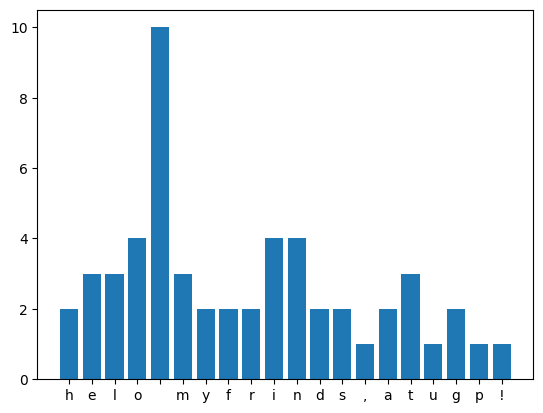

In [ ]:
import matplotlib.pyplot as plt

my_str = "Hello my friends, I am studing Python for a long time!"
my_str = my_str.lower()

word_count = {}
for c in my_str:
    word_count[c] = word_count.get(c, 0) + 1
    
print(word_count)
plt.bar(word_count.keys(), word_count.values())

In [ ]:
my_list = ['ciao', 'bye', 'hello']
def list2dict(lstx):
    new_dict = {}
    for word in my_list:
        new_dict[word[0]] = word
        
    return new_dict

list2dict(my_list)

{'c': 'ciao', 'b': 'bye', 'h': 'hello'}

In [ ]:
my_list = ['ciao', 'bye', 'hello']
def conversion(lstx):
    new_dict = {}
    for word in my_list:
        new_dict[word] = len(word)
        
    return new_dict

conversion(my_list)

{'ciao': 4, 'bye': 3, 'hello': 5}

## YOLO

In [32]:
from ultralytics import YOLO

yolo = YOLO('yolov9m.pt')
images = ["https://homl.info/soccer.jpg", "https://homl.info/traffic.jpg"]
result = yolo(images)
print(result[0].summary()[0])
result[1].summary()[1]


0: 640x640 5 persons, 2 sports balls, 82.1ms
1: 640x640 3 persons, 7 cars, 1 motorcycle, 11 trucks, 82.1ms
Speed: 4.8ms preprocess, 82.1ms inference, 18.5ms postprocess per image at shape (1, 3, 640, 640)
{'name': 'sports ball', 'class': 32, 'confidence': 0.96212, 'box': {'x1': 245.35851, 'y1': 286.03171, 'x2': 300.62524, 'y2': 343.57199}}


{'name': 'truck',
 'class': 7,
 'confidence': 0.908,
 'box': {'x1': 160.65872, 'y1': 111.35687, 'x2': 249.93683, 'y2': 193.30554}}

In [35]:
results = yolo.track("https://homl.info/cars.mp4", stream=True, save=True)
for frame in results:
    summary = frame.summary()
    track_ids = [obj['track_id'] for obj in summary]
    print('Track ID:', track_ids)


Found https://homl.info/cars.mp4 locally at cars.mp4
video 1/1 (frame 1/243) /home/damian/test/ch12/cars.mp4: 384x640 1 person, 8 cars, 1 bus, 1 truck, 26.2ms
Track ID: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
video 1/1 (frame 2/243) /home/damian/test/ch12/cars.mp4: 384x640 8 cars, 1 bus, 1 truck, 26.8ms
Track ID: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
video 1/1 (frame 3/243) /home/damian/test/ch12/cars.mp4: 384x640 8 cars, 1 bus, 1 truck, 26.6ms
Track ID: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
video 1/1 (frame 4/243) /home/damian/test/ch12/cars.mp4: 384x640 7 cars, 1 bus, 1 truck, 26.3ms
Track ID: [1, 2, 3, 4, 5, 6, 7, 8, 10]
video 1/1 (frame 5/243) /home/damian/test/ch12/cars.mp4: 384x640 7 cars, 1 bus, 1 truck, 27.4ms
Track ID: [1, 2, 3, 4, 5, 6, 7, 8, 10]
video 1/1 (frame 6/243) /home/damian/test/ch12/cars.mp4: 384x640 7 cars, 1 bus, 1 truck, 27.8ms
Track ID: [1, 2, 3, 4, 5, 6, 7, 8, 10]
video 1/1 (frame 7/243) /home/damian/test/ch12/cars.mp4: 384x640 7 cars, 1 bus, 1 truck, 30.0ms
Track ID: [1, 2, 